# Row-major vs Spiral Reading — LSTM on 20-Way Coarse CIFAR-100

The experiment: does the **order** pixels enter an LSTM change what it learns? Two models are
trained that are **identical in every respect** — same images, same split, same architecture, same
weight initialization, same training schedule — except for one thing:

- **row-major**: read the image row by row (the original method).
- **spiral**: read it along an outside→center spiral.

In both cases the tensor is `(32 timesteps, 96 features)`; only the pixel ordering differs. The
notebook trains both, then compares learning curves, test metrics, per-class accuracy, and
confusion matrices side by side. Self-contained; runs top-to-bottom in Colab (T4 recommended).


## 1. Setup

In [13]:
import subprocess
import sys


def _ensure(module_name: str, pip_name: str | None = None) -> None:
    try:
        __import__(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or module_name])


_ensure("datasets")
_ensure("sklearn", "scikit-learn")
_ensure("matplotlib")

In [14]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")

import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    top_k_accuracy_score,
)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print("tensorflow:", tf.__version__)

tensorflow: 2.20.0


In [15]:
# --- Run configuration (trains TWO models, one per reading order) ---
NUM_CLASSES = 20          # CIFAR-100 coarse superclasses
SUBSET      = 40000       # train-set size per model. None = full 50k (final run); ~5000 to debug.
EPOCHS      = 45          # EarlyStopping usually stops earlier
BATCH       = 128
HIDDEN      = 128
DROPOUT     = 0.3
LR          = 1e-3
print(f"classes={NUM_CLASSES}  subset={SUBSET}  epochs={EPOCHS}  batch={BATCH}  (x2 models)")

classes=20  subset=40000  epochs=45  batch=128  (x2 models)


## 2. Load CIFAR-100

In [16]:
ds = load_dataset("uoft-cs/cifar100")
train_split, test_split = ds["train"], ds["test"]
coarse_names = train_split.features["coarse_label"].names


def split_to_arrays(split):
    images = np.stack([np.asarray(row["img"].convert("RGB"), dtype=np.uint8) for row in split])
    coarse = np.asarray(split["coarse_label"], dtype=np.int64)
    return images, coarse


train_images, train_coarse = split_to_arrays(train_split)
test_images, test_coarse = split_to_arrays(test_split)
print("train:", train_images.shape, "| test:", test_images.shape, "| classes:", len(coarse_names))

train: (50000, 32, 32, 3) | test: (10000, 32, 32, 3) | classes: 20


## 3. Look at the Data

Coarse CIFAR-100 is balanced (~2,500 per superclass), so accuracy is meaningful and the random
floor is 1/20 = 5%.


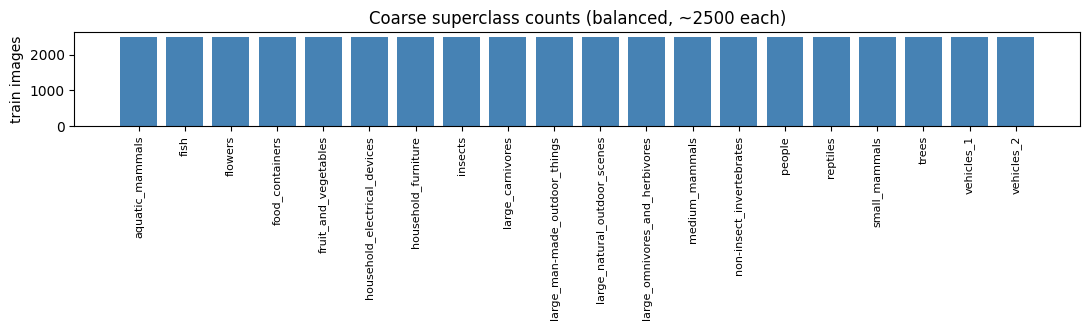

In [17]:
counts = np.bincount(train_coarse, minlength=NUM_CLASSES)
plt.figure(figsize=(11, 3.4))
plt.bar(range(NUM_CLASSES), counts, color="steelblue")
plt.xticks(range(NUM_CLASSES), coarse_names, rotation=90, fontsize=8)
plt.ylabel("train images")
plt.title(f"Coarse superclass counts (balanced, ~{counts.mean():.0f} each)")
plt.tight_layout()
plt.show()

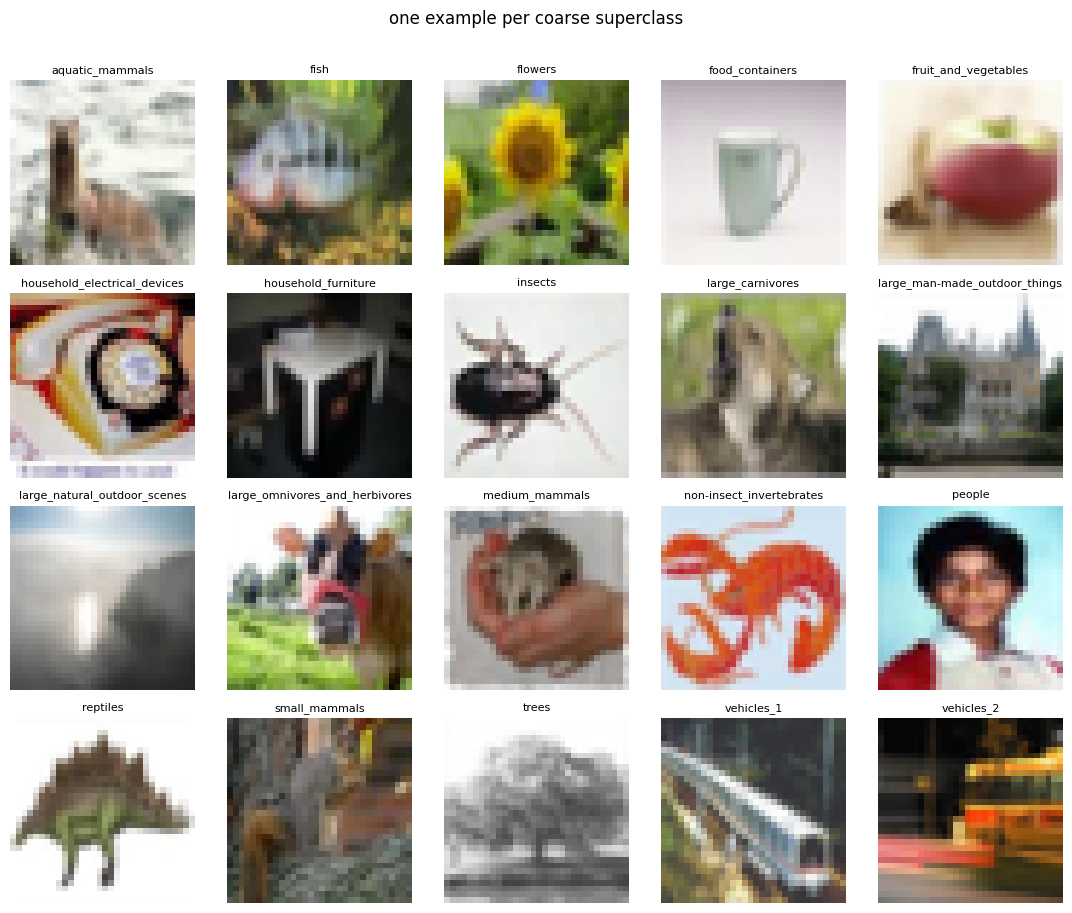

In [18]:
fig, axes = plt.subplots(4, 5, figsize=(11, 9))
for k, ax in enumerate(axes.ravel()):
    j = int(np.flatnonzero(train_coarse == k)[0])
    ax.imshow(train_images[j]); ax.set_title(coarse_names[k], fontsize=8); ax.axis("off")
plt.suptitle("one example per coarse superclass", y=1.01)
plt.tight_layout()
plt.show()

## 4. Stratified Subset + Split (shared by both models)

In [19]:
def stratified_subset(images, labels, *, subset_size, seed):
    if subset_size is None or subset_size >= labels.shape[0]:
        return images, labels
    rng = np.random.default_rng(seed)
    parts = []
    for cls in np.unique(labels):
        idx = np.flatnonzero(labels == cls)
        n_cls = min(max(1, round(subset_size * idx.size / labels.shape[0])), idx.size)
        parts.append(rng.choice(idx, size=n_cls, replace=False))
    sel = np.concatenate(parts)
    if sel.shape[0] > subset_size:
        sel = rng.choice(sel, size=subset_size, replace=False)
    rng.shuffle(sel)
    return images[sel], labels[sel]


def stratified_train_val_split(images, labels, *, val_fraction=0.1, seed=42):
    rng = np.random.default_rng(seed)
    tr, va = [], []
    for cls in np.unique(labels):
        idx = np.flatnonzero(labels == cls)
        rng.shuffle(idx)
        n_val = min(max(1, round(len(idx) * val_fraction)), max(len(idx) - 1, 1))
        va.append(idx[:n_val]); tr.append(idx[n_val:])
    tr, va = np.concatenate(tr), np.concatenate(va)
    rng.shuffle(tr); rng.shuffle(va)
    return images[tr], labels[tr], images[va], labels[va]

## 5. The Two Reading Orders

`to_sequence(images, index)` takes a **pixel ordering** and reshapes to `(N, 32, 96)`. Two orderings:
`ROW_IDX = np.arange(1024)` is the identity — it reproduces the original row-by-row reading exactly
(each timestep is one image row). `SPIRAL_IDX` walks an outside→center spiral. Everything downstream
is shared; the ordering is the *only* difference between the two models.


In [20]:
def build_spiral_index(n: int) -> np.ndarray:
    """Flat pixel indices (r*n + c) visited along an outside->center spiral."""
    order = []
    top, bottom, left, right = 0, n - 1, 0, n - 1
    while top <= bottom and left <= right:
        for c in range(left, right + 1):
            order.append(top * n + c)
        top += 1
        for r in range(top, bottom + 1):
            order.append(r * n + right)
        right -= 1
        if top <= bottom:
            for c in range(right, left - 1, -1):
                order.append(bottom * n + c)
            bottom -= 1
        if left <= right:
            for r in range(bottom, top - 1, -1):
                order.append(r * n + left)
            left += 1
    return np.asarray(order, dtype=np.int64)


ROW_IDX = np.arange(32 * 32)            # identity == original row-by-row reading
SPIRAL_IDX = build_spiral_index(32)     # outside -> center
assert np.array_equal(np.sort(SPIRAL_IDX), ROW_IDX), "spiral index is not a valid permutation"

ORDERINGS = {"row-major": ROW_IDX, "spiral": SPIRAL_IDX}


def to_sequence(images: np.ndarray, index: np.ndarray) -> np.ndarray:
    """Normalize, reorder pixels by `index`, reshape to (N, 32, 96)."""
    if images.ndim != 4 or images.shape[1:] != (32, 32, 3):
        raise ValueError(f"expected (N, 32, 32, 3); got {images.shape}")
    n = images.shape[0]
    flat = (images.astype(np.float32) / 255.0).reshape(n, 32 * 32, 3)
    return flat[:, index, :].reshape(n, 32, 96)


def make_sequence_pipeline(images, labels, index, *, batch_size, shuffle, shuffle_buffer=2048, seed=None):
    seq = to_sequence(images, index)
    ds = tf.data.Dataset.from_tensor_slices((seq, labels.astype(np.int64, copy=False)))
    if shuffle:
        ds = ds.shuffle(shuffle_buffer, seed=seed, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

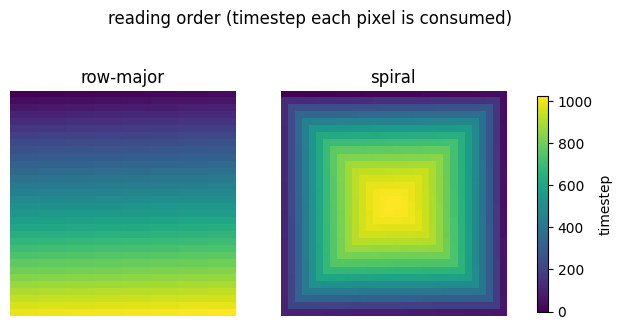

In [21]:
# Side-by-side read orders: dark = read first, bright = read last.
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
im = None
for ax, (name, index) in zip(axes, ORDERINGS.items()):
    omap = np.empty(32 * 32, dtype=np.int64)
    omap[index] = np.arange(32 * 32)
    im = ax.imshow(omap.reshape(32, 32), cmap="viridis")
    ax.set_title(f"{name}"); ax.axis("off")
fig.suptitle("reading order (timestep each pixel is consumed)")
fig.colorbar(im, ax=axes, shrink=0.7, label="timestep")
plt.show()

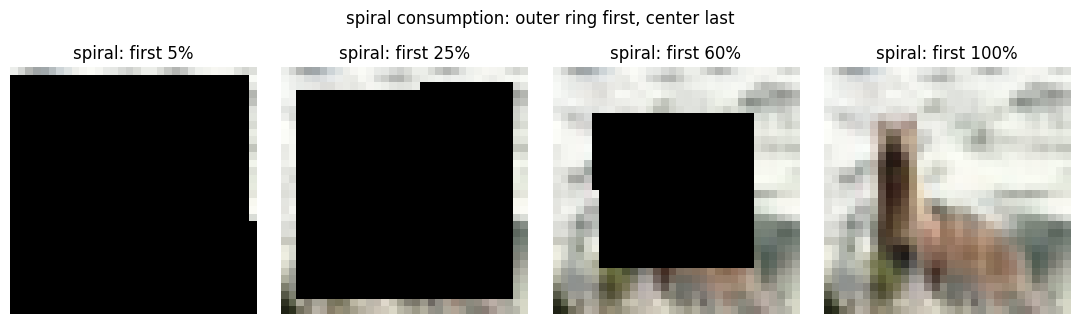

In [22]:
# Illustration: what the spiral model has seen after the first X% of pixels, on a real image.
def reveal(img01, index, frac):
    out = img01.reshape(-1, 3).copy()
    keep = np.zeros(out.shape[0], dtype=bool)
    keep[index[:int(frac * index.shape[0])]] = True
    out[~keep] = 0.0
    return out.reshape(img01.shape)


sample = train_images[int(np.flatnonzero(train_coarse == 0)[0])].astype(np.float32) / 255.0
fracs = [0.05, 0.25, 0.60, 1.0]
fig, axes = plt.subplots(1, len(fracs), figsize=(11, 3.1))
for ax, f in zip(axes, fracs):
    ax.imshow(reveal(sample, SPIRAL_IDX, f)); ax.set_title(f"spiral: first {int(f*100)}%"); ax.axis("off")
plt.suptitle("spiral consumption: outer ring first, center last", y=1.03)
plt.tight_layout()
plt.show()

## 6. LSTM Model

In [23]:
keras = tf.keras
layers = tf.keras.layers


def build_lstm(num_classes=NUM_CLASSES, hidden_units=HIDDEN, dropout=DROPOUT) -> keras.Model:
    """LSTM over (32, 96) -> softmax. tanh keeps the cuDNN fast path; dropout on the final state."""
    inputs = keras.Input(shape=(32, 96), name="sequence")
    x = layers.LSTM(hidden_units, activation="tanh")(inputs)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="probs")(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="lstm")


build_lstm().summary()

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence (InputLayer)           │ (None, 32, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,780 (460.08 KB)

 Trainable params: 117,780 (460.08 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train Both Models

Same split, same architecture, **same weight initialization** (the seed is reset before each build),
same optimizer and callbacks. The loop's only changing input is the pixel ordering, so any difference
in the results below is attributable to reading order alone.


In [24]:
# Shared split — both models train on exactly these images.
img_tr, y_tr_s = stratified_subset(train_images, train_coarse, subset_size=SUBSET, seed=SEED)
x_tr, y_tr, x_val, y_val = stratified_train_val_split(img_tr, y_tr_s, val_fraction=0.1, seed=SEED)
print(f"shared split: train {x_tr.shape[0]}  val {x_val.shape[0]}  test {test_images.shape[0]}")

y_true = test_coarse.astype(np.int64)
labels20 = list(range(NUM_CLASSES))
results = {}

for order_name, index in ORDERINGS.items():
    print(f"\n{'='*56}\nTraining: {order_name}\n{'='*56}")
    train_ds = make_sequence_pipeline(x_tr, y_tr, index, batch_size=BATCH, shuffle=True, seed=SEED)
    val_ds   = make_sequence_pipeline(x_val, y_val, index, batch_size=BATCH, shuffle=False)
    test_ds  = make_sequence_pipeline(test_images, test_coarse, index, batch_size=BATCH, shuffle=False)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)      # identical initialization for a fair comparison
    model = build_lstm()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy", tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3")],
    )
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)

    y_prob = model.predict(test_ds, verbose=0)
    y_pred = y_prob.argmax(axis=1)
    cm = confusion_matrix(y_true, y_pred, labels=labels20)
    results[order_name] = {
        "history":   history.history,
        "y_pred":    y_pred,
        "top1":      accuracy_score(y_true, y_pred),
        "top3":      top_k_accuracy_score(y_true, y_prob, k=3, labels=labels20),
        "top5":      top_k_accuracy_score(y_true, y_prob, k=5, labels=labels20),
        "macro_f1":  f1_score(y_true, y_pred, average="macro", zero_division=0),
        "cm":        cm,
        "per_class": cm.diagonal() / cm.sum(axis=1).clip(min=1),
    }
    r = results[order_name]
    print(f"  {order_name}: top-1={r['top1']:.3f}  top-3={r['top3']:.3f}  macro-F1={r['macro_f1']:.3f}")

shared split: train 36000  val 4000  test 10000

Training: row-major
Epoch 1/45
282/282 - 30s - 108ms/step - accuracy: 0.1663 - loss: 2.6870 - top3: 0.3711 - val_accuracy: 0.2307 - val_loss: 2.4505 - val_top3: 0.4678 - learning_rate: 0.0010
Epoch 2/45
282/282 - 28s - 99ms/step - accuracy: 0.2426 - loss: 2.4420 - top3: 0.4775 - val_accuracy: 0.2775 - val_loss: 2.3456 - val_top3: 0.5115 - learning_rate: 0.0010
Epoch 3/45
282/282 - 27s - 95ms/step - accuracy: 0.2778 - loss: 2.3358 - top3: 0.5212 - val_accuracy: 0.2915 - val_loss: 2.2999 - val_top3: 0.5225 - learning_rate: 0.0010
Epoch 4/45
282/282 - 41s - 145ms/step - accuracy: 0.3010 - loss: 2.2686 - top3: 0.5448 - val_accuracy: 0.3147 - val_loss: 2.1986 - val_top3: 0.5685 - learning_rate: 0.0010
Epoch 5/45
282/282 - 28s - 98ms/step - accuracy: 0.3174 - loss: 2.2084 - top3: 0.5677 - val_accuracy: 0.3195 - val_loss: 2.1893 - val_top3: 0.5633 - learning_rate: 0.0010
Epoch 6/45
282/282 - 27s - 95ms/step - accuracy: 0.3309 - loss: 2.1628 - t

## 8. Compare — Learning Curves

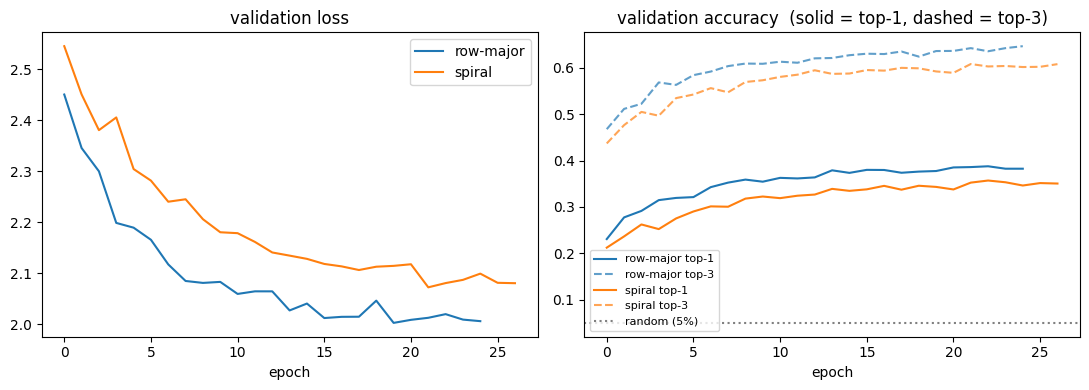

In [25]:
colors = {"row-major": "tab:blue", "spiral": "tab:orange"}
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for name, r in results.items():
    h = r["history"]
    ax[0].plot(h["val_loss"], color=colors[name], label=name)
    ax[1].plot(h["val_accuracy"], color=colors[name], label=f"{name} top-1")
    ax[1].plot(h["val_top3"], color=colors[name], ls="--", alpha=0.7, label=f"{name} top-3")
ax[0].set_title("validation loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].axhline(1 / NUM_CLASSES, color="gray", ls=":", label="random (5%)")
ax[1].set_title("validation accuracy  (solid = top-1, dashed = top-3)")
ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Compare — Test Metrics

method         top-1   top-3   top-5  macro-F1
------------------------------------------------
row-major      0.382   0.638   0.764     0.380
spiral         0.354   0.608   0.738     0.347


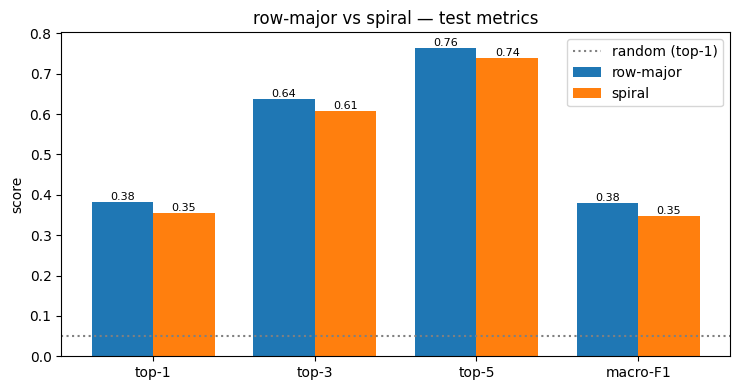

In [26]:
print(f"{'method':<12}{'top-1':>8}{'top-3':>8}{'top-5':>8}{'macro-F1':>10}")
print("-" * 48)
for name, r in results.items():
    print(f"{name:<12}{r['top1']:>8.3f}{r['top3']:>8.3f}{r['top5']:>8.3f}{r['macro_f1']:>10.3f}")

metric_keys = ["top1", "top3", "top5", "macro_f1"]
metric_labels = ["top-1", "top-3", "top-5", "macro-F1"]
xs = np.arange(len(metric_keys))
width = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4))
for i, (name, r) in enumerate(results.items()):
    vals = [r[k] for k in metric_keys]
    bars = ax.bar(xs + (i - 0.5) * width, vals, width, label=name, color=colors[name])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.2f}", ha="center", fontsize=8)
ax.axhline(1 / NUM_CLASSES, color="gray", ls=":", label="random (top-1)")
ax.set_xticks(xs); ax.set_xticklabels(metric_labels); ax.set_ylabel("score")
ax.set_title("row-major vs spiral — test metrics"); ax.legend()
plt.tight_layout()
plt.show()

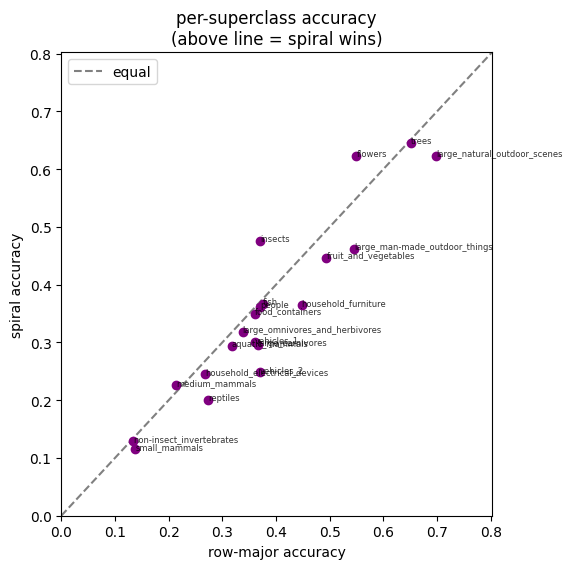

In [27]:
# Per-superclass: above the diagonal = spiral better for that class.
row_pc = results["row-major"]["per_class"]
spi_pc = results["spiral"]["per_class"]
lim = max(row_pc.max(), spi_pc.max(), 0.1) * 1.15
plt.figure(figsize=(5.8, 5.8))
plt.scatter(row_pc, spi_pc, color="purple", zorder=3)
plt.plot([0, lim], [0, lim], color="gray", ls="--", label="equal")
for k in range(NUM_CLASSES):
    plt.annotate(coarse_names[k], (row_pc[k], spi_pc[k]), fontsize=6, alpha=0.8)
plt.xlim(0, lim); plt.ylim(0, lim)
plt.xlabel("row-major accuracy"); plt.ylabel("spiral accuracy")
plt.title("per-superclass accuracy\n(above line = spiral wins)")
plt.legend()
plt.tight_layout()
plt.show()

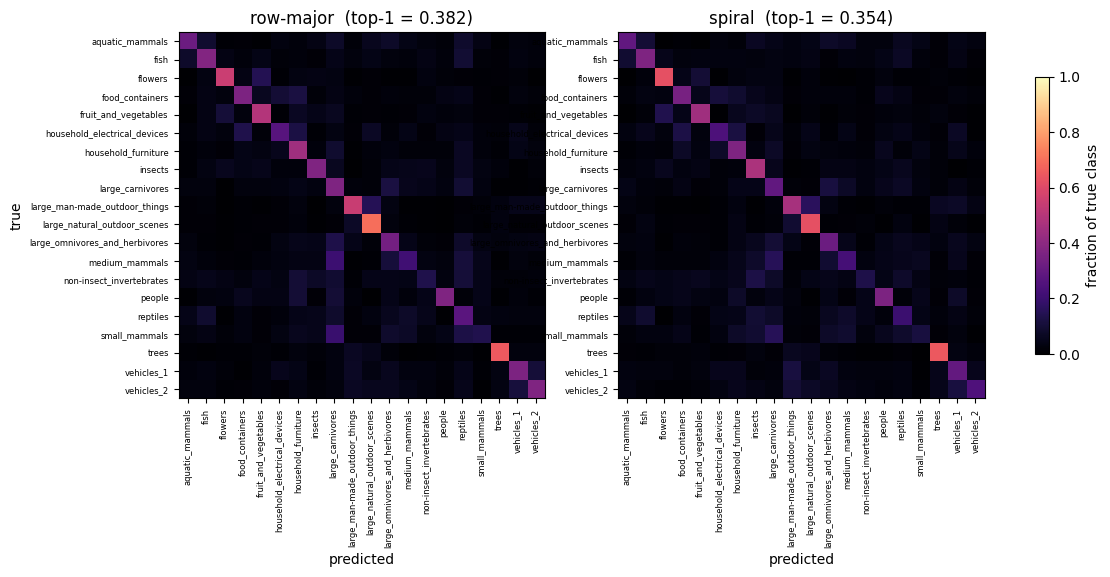

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
im = None
for ax, (name, r) in zip(axes, results.items()):
    cmn = r["cm"] / r["cm"].sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cmn, cmap="magma", vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(coarse_names, rotation=90, fontsize=6)
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(coarse_names, fontsize=6)
    ax.set_title(f"{name}  (top-1 = {r['top1']:.3f})"); ax.set_xlabel("predicted")
axes[0].set_ylabel("true")
fig.colorbar(im, ax=axes, shrink=0.6, label="fraction of true class")
plt.show()

## Interpretation

Read the comparison off the metrics table and the learning curves. Because the two models differ
**only** in pixel ordering — same images, same init, same schedule — any gap is the effect of
serialization order itself, which is the claim the project can make.

What to expect: both are weak (a serialized image is hard for an LSTM), so both land well above the
5% floor but far below a CNN, and top-3/top-5 sit much higher than top-1. Whether spiral *beats*
row-major is the open question this answers — a spiral keeps each concentric ring's pixels close in
time, which may help classes with a strong center-vs-surround structure; the per-superclass scatter
shows exactly which classes each ordering favors. Note that with a single seed this is one run, not a
significance test; to make the claim robust, rerun with a few `SEED` values and check the gap holds.
